# ***Real-Time Public Transport Delay Prediction***

### Project Type : Classification



---



## ***Project Summary***
Public transport is an important part of city mobility and delays in buses, trains and other transport services can have a significant impact on commuters, operational efficiency and city traffic management. Forecasting transport delays in advance enables transport authorities and passengers to make informed decisions, optimize schedules and improve overall service reliability.

The project "Real-Time Public Transport Delay Prediction" aims to build a classification system using machine learning to predict whether a public transport trip will be delayed. The dataset includes historical transportation data like scheduled and actual departure and arrival times, weather conditions, traffic congestion levels, holidays, peak hours, information about events, seasonal effects, and environmental factors like temperature, humidity, wind speed, and precipitation.

The project starts with detailed exploratory data analysis (EDA) to understand the structure of the dataset, to find missing values, to find outliers, and to analyze relationships between variables. Different visualizations are generated to find out the patterns and factors that cause delays. Statistical hypothesis testing is used to test the assumptions of weather, traffic jams and peak hours effects on delays.

Feature Engineering Techniques are applied to convert date and time information into meaningful features and encode categorical variables for machine learning algorithms. Steps such as handling missing values, outlier treatment, feature scaling and feature selection are performed to improve the model performance.

Various performance metrics like Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score are used to train and evaluate the performance of multiple classification algorithms like Logistic Regression, Random Forest, and XGBoost. Cross-validation and hyper-parameter tuning techniques are applied to optimize the model performance and reduce the overfitting.

The final model can help transportation authorities proactively manage delays, improve passenger satisfaction, optimize resource allocation, and support intelligent transportation systems. The project demonstrates how data science and machine learning can be used to build smarter, more efficient public transportation systems, through the real-time prediction of delays.


---



## ***Github Link***



---



## ***Problem Statement***
There is an ever-growing need for efficient public transportation, and intelligent systems are required to predict any delay that might occur in advance. Delays are caused by many reasons such as the weather, heavy traffic, festive days, rush hours, special events, and seasonality. The aim of this project is to examine historical data about public transport and create a machine learning algorithm that predicts whether the journey of the public transport will be delayed or not.


---



# ***Let's Begin***

## ***Knowing our Data***

In [ ]:
# Data Manipulation Libraries
import numpy as np
import pandas as pd

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Libraries
from scipy import stats

# Preprocessing Libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Loading Dataset
df = pd.read_csv('/content/public_transport_delays.csv')
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [ ]:
# Rows & Columns
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2000
Columns : 24


In [ ]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [ ]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows :", duplicate_count)

Duplicate Rows : 0


In [ ]:
# Checking missing values
df.isnull().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100

pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
}).sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
event_type,1173,58.65
trip_id,0,0.00
time,0,0.00
date,0,0.00
route_id,0,0.00
origin_station,0,0.00
destination_station,0,0.00
transport_type,0,0.00
scheduled_departure,0,0.00
scheduled_arrival,0,0.00


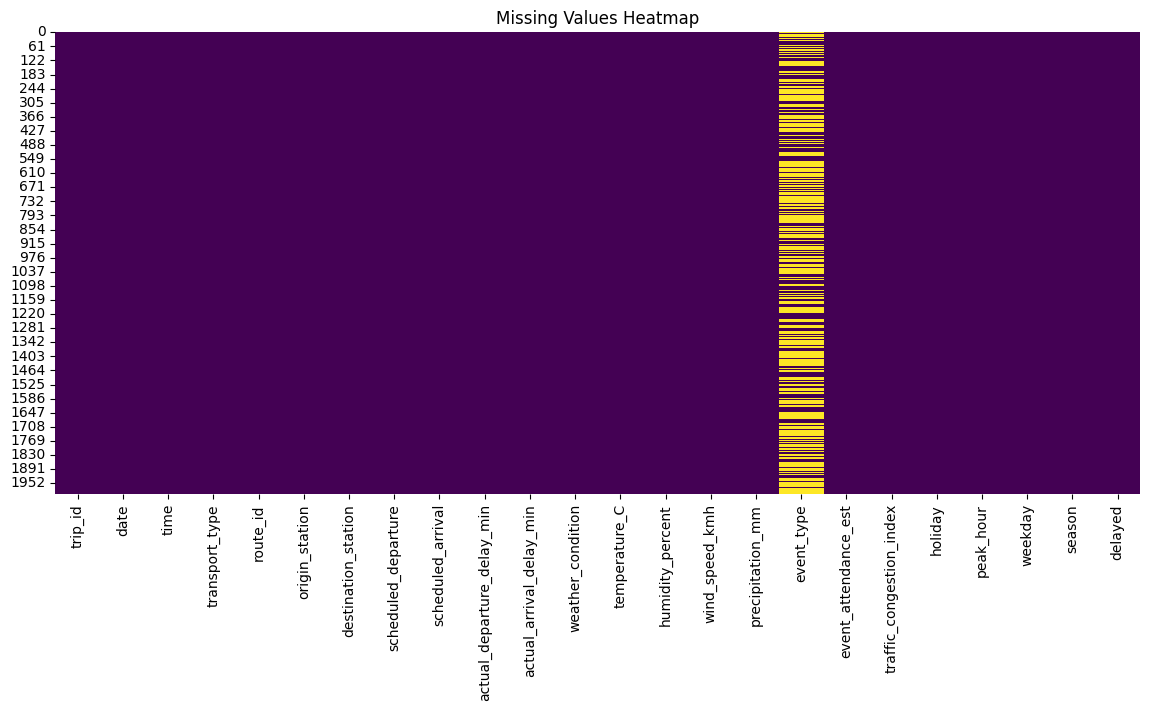

In [ ]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# ==========================
# DATE CONVERSION
# ==========================

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract useful date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

# Weekend Flag
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)


# ==========================
# TIME CONVERSIONS
# ==========================

df['time'] = pd.to_datetime(
    df['time'],
    format='%H:%M:%S',
    errors='coerce'
)

df['scheduled_departure'] = pd.to_datetime(
    df['scheduled_departure'],
    format='%H:%M:%S',
    errors='coerce'
)

df['scheduled_arrival'] = pd.to_datetime(
    df['scheduled_arrival'],
    format='%H:%M:%S',
    errors='coerce'
)


# ==========================
# EXTRACT TIME FEATURES
# ==========================

df['trip_hour'] = df['time'].dt.hour
df['trip_minute'] = df['time'].dt.minute

df['departure_hour'] = df['scheduled_departure'].dt.hour
df['departure_minute'] = df['scheduled_departure'].dt.minute

df['arrival_hour'] = df['scheduled_arrival'].dt.hour
df['arrival_minute'] = df['scheduled_arrival'].dt.minute


# ==========================
# RUSH PERIOD FEATURE
# ==========================

def rush_period(hour):
    if 7 <= hour <= 10:
        return 'Morning Peak'
    elif 17 <= hour <= 20:
        return 'Evening Peak'
    else:
        return 'Non Peak'

df['rush_period'] = df['departure_hour'].apply(rush_period)


# ==========================
# TRIP DURATION (IN MINUTES)
# ==========================

df['trip_duration_min'] = (
    (
        df['scheduled_arrival']
        - df['scheduled_departure']
    ).dt.total_seconds()
) / 60


# Handle trips crossing midnight
df.loc[
    df['trip_duration_min'] < 0,
    'trip_duration_min'
] += 24 * 60


# ==========================
# CHECK FOR NaT VALUES
# ==========================

print(df[['date',
          'time',
          'scheduled_departure',
          'scheduled_arrival']].isnull().sum())

date                   0
time                   0
scheduled_departure    0
scheduled_arrival      0
dtype: int64


In [ ]:
# Dropping those columns which causes leakage and inconsistent ML model learning
drop_cols = [
    'trip_id',
    'actual_departure_delay_min',
    'actual_arrival_delay_min'
]

df = df.drop(columns=drop_cols)

In [ ]:
# Handling Null Values
df['event_type'] = df['event_type'].fillna('No Event')

In [ ]:
# Sanity Check for Null Values and its categories
df['event_type'].isnull().sum()
df['event_type'].value_counts(dropna=False)

,count
event_type,
No Event,1173
Festival,221
Sports,212
Concert,203
Parade,105
Protest,86


## ***Pre EDA Analysis***

### 1. Checking the Target Variable Distribution

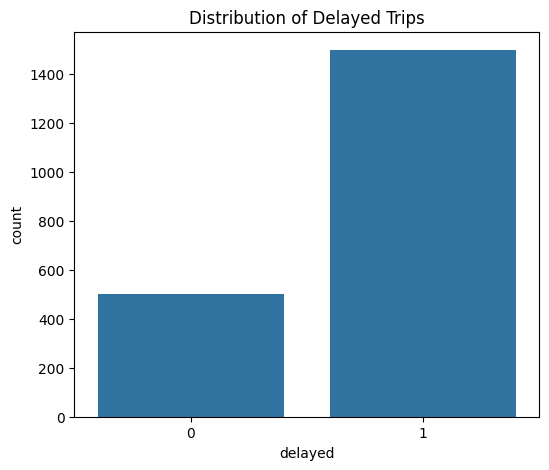

In [ ]:
df['delayed'].value_counts()
df['delayed'].value_counts(normalize=True)*100

plt.figure(figsize=(6,5))
sns.countplot(x='delayed', data=df)
plt.title('Distribution of Delayed Trips')
plt.show()

From the chart:

Class 0 (Not Delayed): ~500 observations      
Class 1 (Delayed): ~1500 observations

Approximate percentages:

Not Delayed (0): 25%               
Delayed (1): 75%

Target Variable is imbalanced. Majority has Delayed(1) -> 75%          
Minority has Not Delayed(0) -> 25%

Roughly 3:1 Class Imbalance

When training model, it may only predict delayed as its majority so rather to focus on Accuracy Metrics, we'll also consider Precision, Recall, F1-s, ROC-AUC.

Note :- No SMOTE required, as 75:25 imbalance is moderate, not severe.

## 2. Checking Numerical Features

In [ ]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

num_cols

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_C,2000.0,15.12135,11.479424,-5.0,5.1,15.3,24.8,35.0
humidity_percent,2000.0,64.71400,20.334747,30.0,46.0,65.0,83.0,99.0
wind_speed_kmh,2000.0,29.30050,17.264015,0.0,15.0,29.0,45.0,59.0
precipitation_mm,2000.0,9.86070,5.781373,0.0,4.9,9.7,14.8,20.0
event_attendance_est,2000.0,6420.25000,15198.306129,0.0,0.0,0.0,2000.0,50000.0
traffic_congestion_index,2000.0,50.24400,29.225751,0.0,25.0,50.0,76.0,99.0
holiday,2000.0,0.08950,0.285535,0.0,0.0,0.0,0.0,1.0
peak_hour,2000.0,0.27200,0.445101,0.0,0.0,0.0,1.0,1.0
weekday,2000.0,2.97600,1.990328,0.0,1.0,3.0,5.0,6.0
delayed,2000.0,0.74950,0.433409,0.0,0.0,1.0,1.0,1.0


Most numerical features showed realistic ranges and did not contain significant outliers.

## 3. Check Categorical Features

In [ ]:
cat_cols = df.select_dtypes(
    include=['object','category']
).columns

cat_cols

for col in cat_cols:
    print('\n', col)
    print(df[col].value_counts())


 transport_type
transport_type
Bus      525
Train    493
Metro    491
Tram     491
Name: count, dtype: int64

 route_id
route_id
Route_3     114
Route_15    112
Route_13    112
Route_2     110
Route_17    110
Route_8     109
Route_12    105
Route_14    105
Route_4     104
Route_18    101
Route_9     101
Route_5      98
Route_20     97
Route_6      97
Route_19     95
Route_7      89
Route_11     88
Route_1      87
Route_10     86
Route_16     80
Name: count, dtype: int64

 origin_station
origin_station
Station_17    55
Station_47    51
Station_32    49
Station_40    49
Station_13    49
Station_49    49
Station_28    47
Station_29    47
Station_22    46
Station_38    45
Station_45    45
Station_48    44
Station_15    44
Station_20    43
Station_23    43
Station_43    42
Station_8     42
Station_4     42
Station_26    41
Station_19    41
Station_3     41
Station_21    41
Station_25    40
Station_10    40
Station_1     40
Station_50    39
Station_35    39
Station_11    39
Station_36    38

## Checking Cardinality

In [ ]:
for col in cat_cols:
    print(col,
          ':',
          df[col].nunique())

transport_type : 4
route_id : 20
origin_station : 50
destination_station : 50
weather_condition : 6
event_type : 6
season : 4
day_name : 7
rush_period : 3


## Correlation with Target

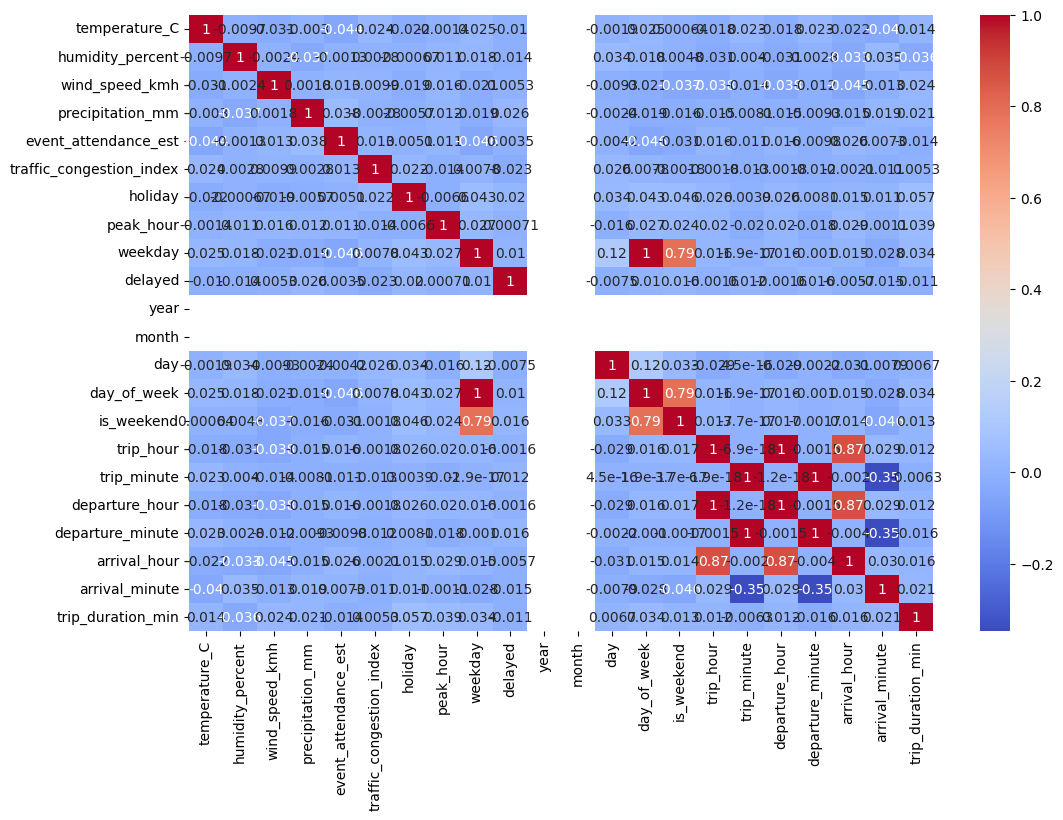

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

###

In [ ]:
# Event Present
df['event_present'] = (
    df['event_type'] != 'No Event'
).astype(int)

# Bad Weather
df['bad_weather'] = (
    df['weather_condition'].isin(
        ['Rain','Snow','Storm','Fog']
    )
).astype(int)

# High Traffic
df['high_traffic'] = (
    df['traffic_congestion_index'] >= 70
).astype(int)

# Heavy Rain
df['heavy_rain'] = (
    df['precipitation_mm'] >= 15
).astype(int)

In [ ]:
# Drop redundant feature
df.drop('day_name', axis=1, inplace=True)

# Create engineered features
df['event_present'] = (df['event_type'] != 'No Event').astype(int)
df['bad_weather'] = df['weather_condition'].isin(
    ['Rain','Snow','Storm','Fog']
).astype(int)
df['high_traffic'] = (df['traffic_congestion_index'] >= 70).astype(int)
df['heavy_rain'] = (df['precipitation_mm'] >= 15).astype(int)



---



## ***EDA (Exploratory Data Analysis)***



## Univariate Analysis

Chart 1: Distribution of Target Variable (delayed)

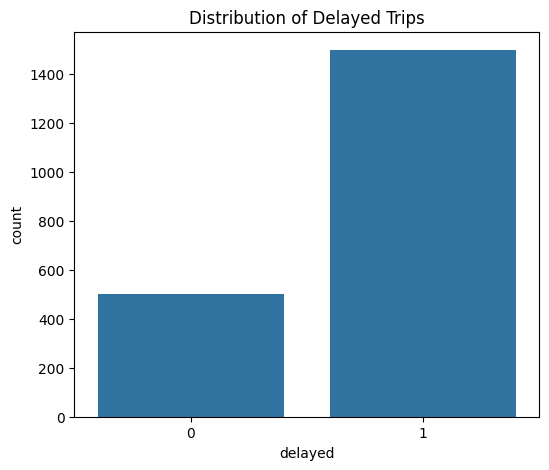

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(x='delayed', data=df)
plt.title('Distribution of Delayed Trips')
plt.show()

### Chart 2: Transport Type Distribution

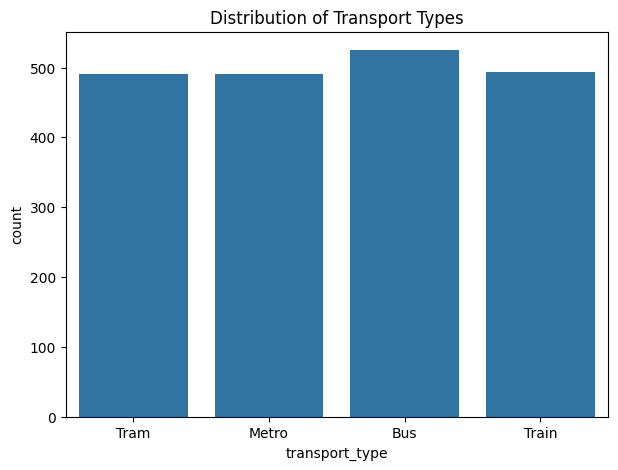

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='transport_type', data=df)
plt.title('Distribution of Transport Types')
plt.show()

### Chart 3: Weather Condition Distribution

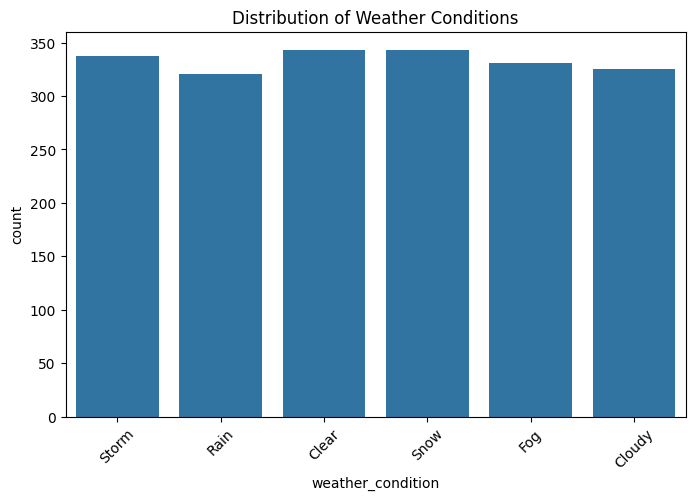

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='weather_condition', data=df)
plt.title('Distribution of Weather Conditions')
plt.xticks(rotation=45)
plt.show()

### Chart 4: Event Type Distribution

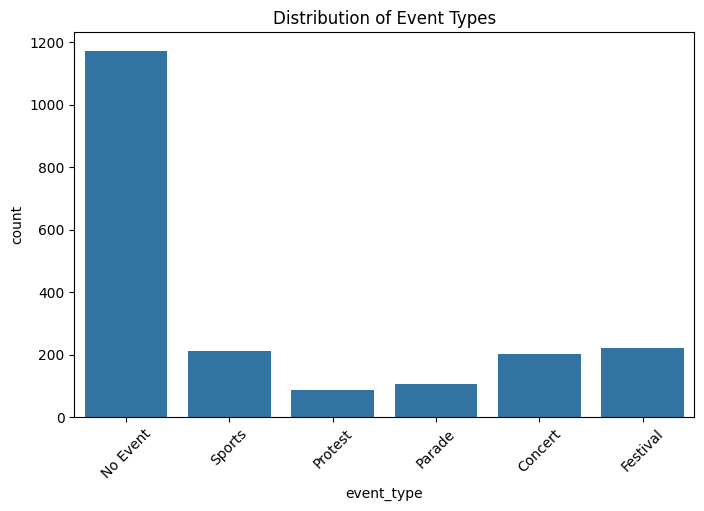

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='event_type', data=df)
plt.title('Distribution of Event Types')
plt.xticks(rotation=45)
plt.show()

### Chart 5: Trip Duration Distribution

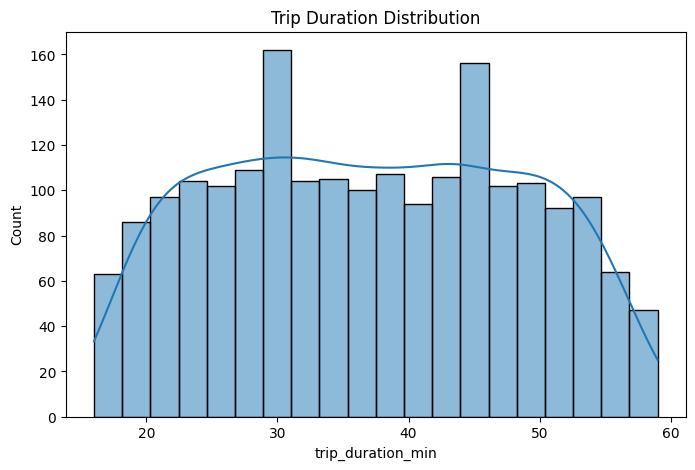

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['trip_duration_min'],
             bins=20,
             kde=True)

plt.title('Trip Duration Distribution')
plt.show()

### Chart 6: Traffic Congestion Distribution

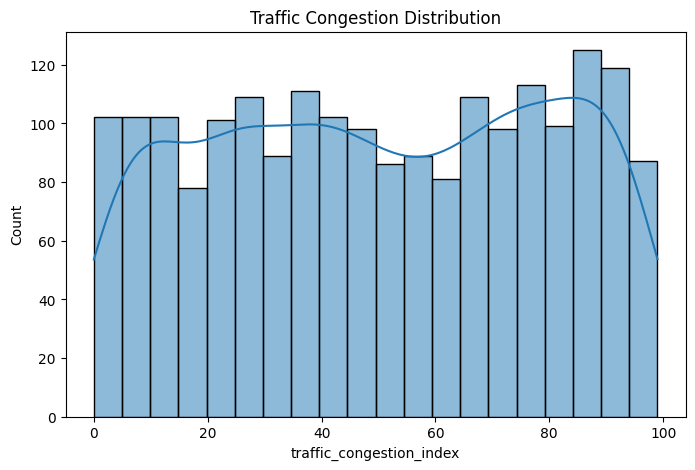

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_congestion_index'],
             bins=20,
             kde=True)

plt.title('Traffic Congestion Distribution')
plt.show()



---



## Bivariate Analysis

## Chart 7: Delays by Transport Type

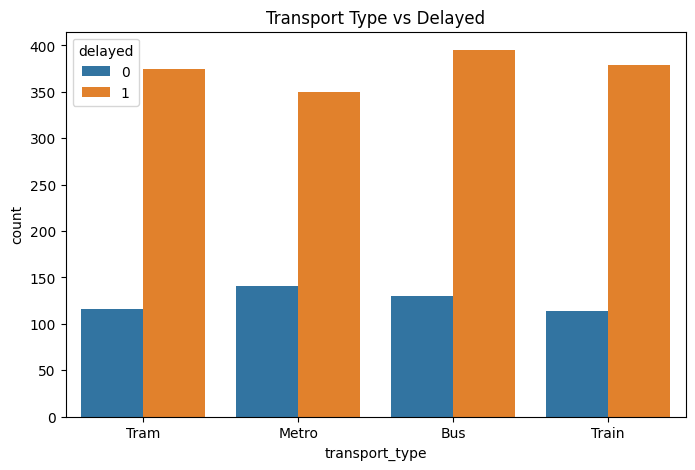

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='transport_type',
    hue='delayed',
    data=df
)

plt.title('Transport Type vs Delayed')
plt.show()

## Chart 8: Delays by Weather Condition

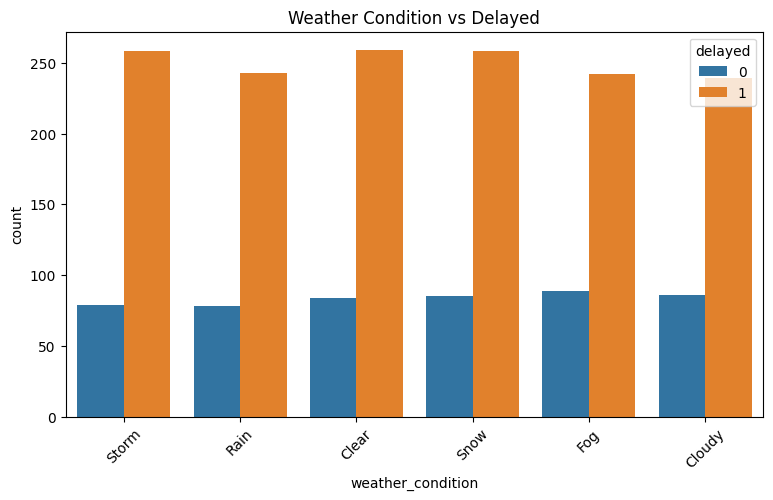

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(
    x='weather_condition',
    hue='delayed',
    data=df
)

plt.title('Weather Condition vs Delayed')
plt.xticks(rotation=45)
plt.show()

## Chart 9: Delays by Event Type

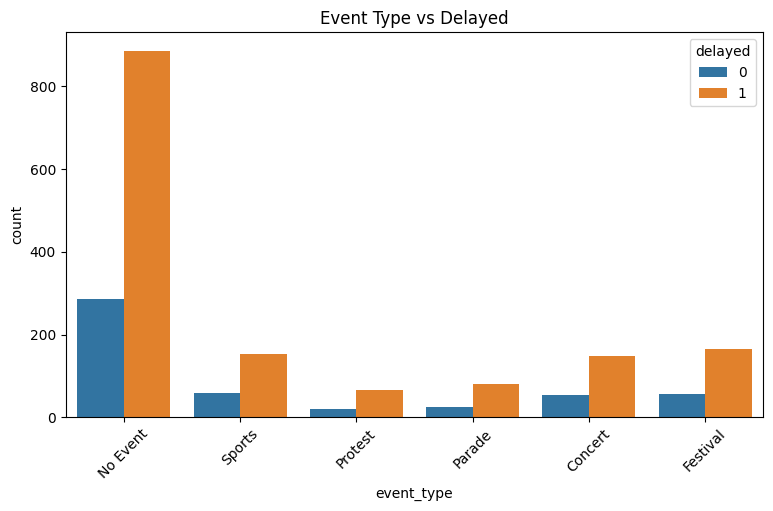

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(
    x='event_type',
    hue='delayed',
    data=df
)

plt.title('Event Type vs Delayed')
plt.xticks(rotation=45)
plt.show()

## Chart 10: Delays by Rush Period

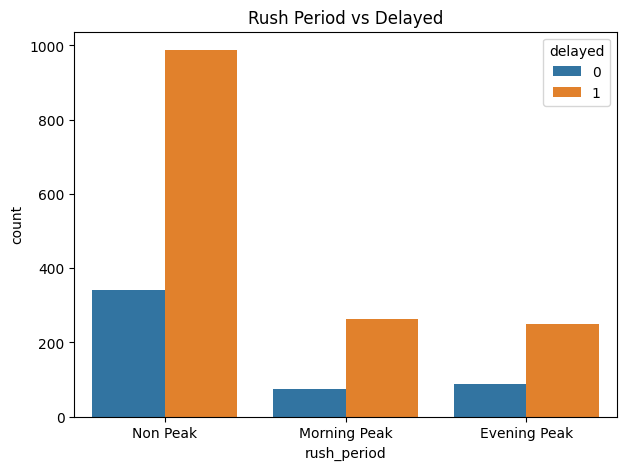

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='rush_period',
    hue='delayed',
    data=df
)

plt.title('Rush Period vs Delayed')
plt.show()

## Chart 11: Traffic Congestion vs Delayed

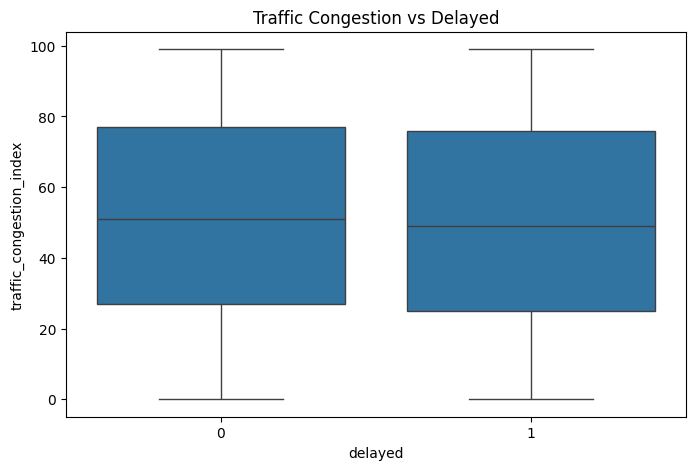

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='delayed',
    y='traffic_congestion_index',
    data=df
)

plt.title('Traffic Congestion vs Delayed')
plt.show()

## Chart 12: Trip Duration vs Delayed

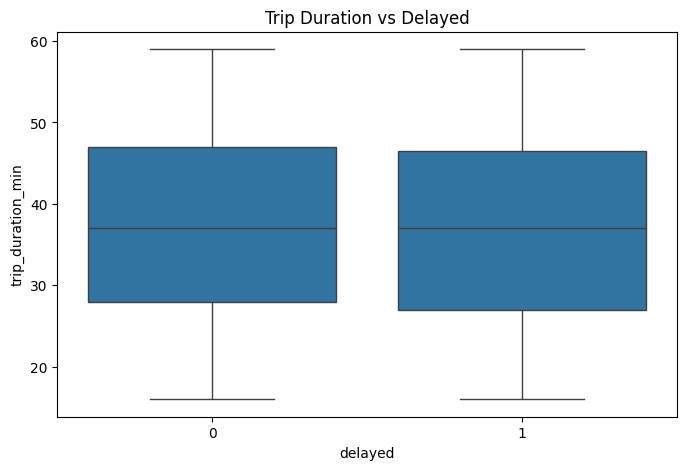

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='delayed',
    y='trip_duration_min',
    data=df
)

plt.title('Trip Duration vs Delayed')
plt.show()

## Multivariate Analysis

## Chart 13: Correlation Heatmap

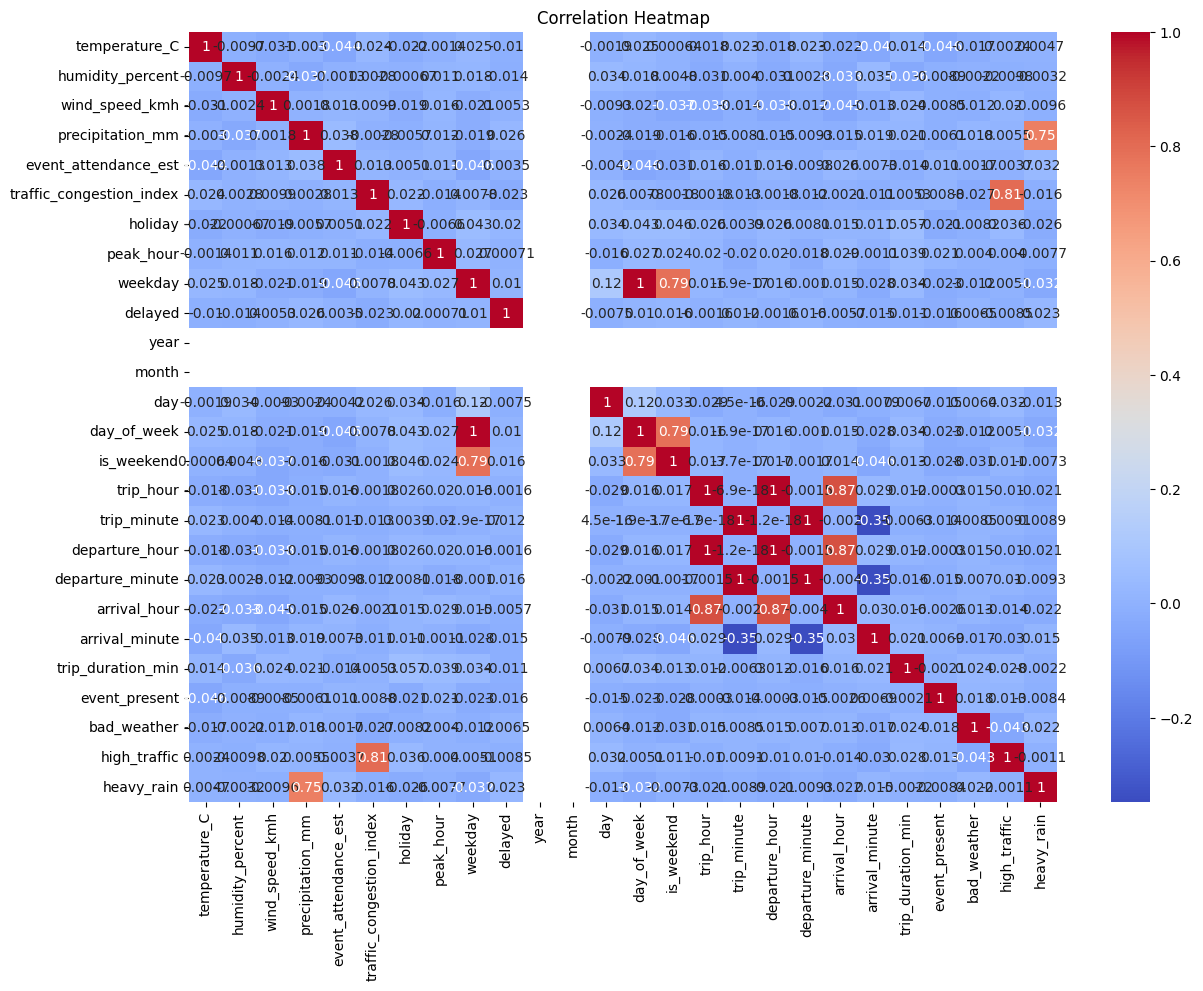

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

## Hypothesis Testing


# Hypothesis 1: Traffic Congestion and Delays

**Null Hypothesis (H₀)**

There is no significant relationship between traffic_congestion_index and whether a trip is delayed.

**Alternate Hypothesis (H₁)**

There is a significant relationship between traffic_congestion_index and whether a trip is delayed.

In [ ]:
# Test: Independent Samples t-Test
from scipy.stats import ttest_ind

delayed = df[df['delayed'] == 1]['traffic_congestion_index']
not_delayed = df[df['delayed'] == 0]['traffic_congestion_index']

t_stat, p_value = ttest_ind(delayed, not_delayed)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.0449181735752857
P-value: 0.29618719021080814


# Hypothesis 2: Weather Conditions Affect Delays

**Null Hypothesis (H₀)**

Weather conditions have no association with transport delays.


**Alternate Hypothesis (H₁)**

Weather conditions are associated with transport delays.

In [ ]:
# Test: Chi-Square Test
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['weather_condition'],
    df['delayed']
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 1.5715815710755934
P-value: 0.9046644317672604


# Hypothesis 3: Event Attendance Influences Delays

**Null Hypothesis (H₀)**

Mean event_attendance_est is the same for delayed and non-delayed trips.

**Alternate Hypothesis (H₁)**

Mean event_attendance_est differs between delayed and non-delayed trips.

In [ ]:
# Test: Independent Samples t-Test

delayed = df[df['delayed'] == 1]['event_attendance_est']
not_delayed = df[df['delayed'] == 0]['event_attendance_est']

t_stat, p_value = ttest_ind(delayed, not_delayed)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.15630719371885954
P-value: 0.8758066774159322


# Decision Rule

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


For every test:

If p-value < 0.05: Reject H₀ → Significant relationship exists.
If p-value ≥ 0.05: Fail to reject H₀ → No significant evidence of a relationship.

# Feature Engineering & Data PreProcessing

In [ ]:
df_model = df.copy()

In [ ]:
drop_cols = [
    'trip_id',
    'actual_departure_delay_min',
    'actual_arrival_delay_min'
]

df_model = df_model.drop(columns=drop_cols, errors='ignore')

In [ ]:
df_model['event_type'] = df_model['event_type'].fillna('No Event')

In [ ]:
df_model['date'] = pd.to_datetime(
    df_model['date'],
    errors='coerce'
)

df_model['time'] = pd.to_datetime(
    df_model['time'],
    errors='coerce'
)

df_model['scheduled_departure'] = pd.to_datetime(
    df_model['scheduled_departure'],
    errors='coerce'
)

df_model['scheduled_arrival'] = pd.to_datetime(
    df_model['scheduled_arrival'],
    errors='coerce'
)

In [ ]:
df_model['month'] = df_model['date'].dt.month

df_model['day'] = df_model['date'].dt.day

df_model['day_of_week'] = (
    df_model['date']
    .dt.dayofweek
)

df_model['is_weekend'] = (
    df_model['day_of_week']
    .isin([5, 6])
    .astype(int)
)

In [ ]:
df_model['trip_hour'] = (
    df_model['time']
    .dt.hour
)

df_model['departure_hour'] = (
    df_model['scheduled_departure']
    .dt.hour
)

df_model['arrival_hour'] = (
    df_model['scheduled_arrival']
    .dt.hour
)

In [ ]:
df_model['trip_duration_min'] = (
    (
        df_model['scheduled_arrival']
        - df_model['scheduled_departure']
    )
    .dt.total_seconds()
    / 60
)

In [ ]:
df_model.loc[
    df_model['trip_duration_min'] < 0,
    'trip_duration_min'
] += 24 * 60

In [ ]:
df_model['event_present'] = (
    df_model['event_type']
    != 'No Event'
).astype(int)

In [ ]:
df_model['bad_weather'] = (
    df_model['weather_condition']
    .isin(
        ['Rain', 'Snow', 'Storm', 'Fog']
    )
).astype(int)

In [ ]:
df_model['high_traffic'] = (
    df_model['traffic_congestion_index']
    >= 70
).astype(int)

In [ ]:
df_model['heavy_rain'] = (
    df_model['precipitation_mm']
    >= 15
).astype(int)

In [ ]:
df_model['event_attendance_log'] = np.log1p(
    df_model['event_attendance_est']
)

In [ ]:
datetime_cols = [
    'date',
    'time',
    'scheduled_departure',
    'scheduled_arrival'
]

df_model = df_model.drop(
    columns=datetime_cols,
    errors='ignore'
)

In [ ]:
df = df.drop(
    columns=[
        'trip_minute',
        'departure_minute',
        'arrival_minute'
    ]
)

In [ ]:
origin_freq = df['origin_station'].value_counts()
df['origin_station_freq'] = df['origin_station'].map(origin_freq)

destination_freq = df['destination_station'].value_counts()
df['destination_station_freq'] = df['destination_station'].map(destination_freq)

In [ ]:
df = df.drop(
    columns=[
        'origin_station',
        'destination_station'
    ]
)

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'transport_type',
        'route_id',
        'weather_condition',
        'event_type',
        'season',
        'rush_period'
    ],
    drop_first=True,
    dtype=int
)

In [ ]:
df = df.drop(
    columns=[
        'date',
        'time',
        'scheduled_departure',
        'scheduled_arrival'
    ]
)

In [ ]:
df = df.drop(columns=['year', 'month'], errors='ignore') #########################################

In [ ]:
X = df.drop(columns='delayed')
y = df['delayed']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ***Model Building***

## 1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
ROC AUC  : 0.4095


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400



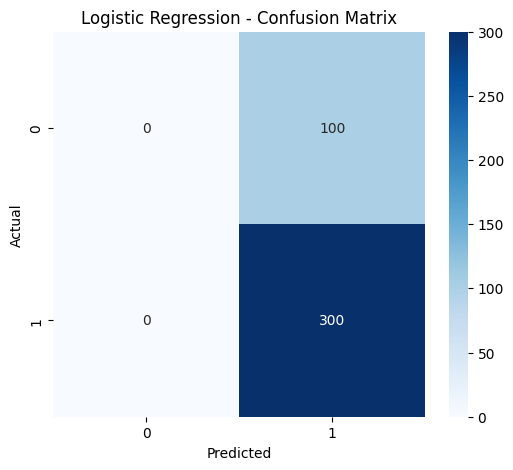

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross Validation Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross Validation Scores: [0.85509839 0.85509839 0.85098743 0.85714286 0.85509839]
Mean F1 Score: 0.854685091952847


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.8567339637107079


In [ ]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)
y_prob_best = best_lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_best))

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
ROC AUC  : 0.5


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

delayed
1    1199
0     401
Name: count, dtype: int64
delayed
1    300
0    100
Name: count, dtype: int64


# Logistic Regression Model Analysis
Evaluation Metrics

| Metric    |      Value | Interpretation                                                            |
| --------- | ---------: | ------------------------------------------------------------------------- |
| Accuracy  |   **0.75** | Appears good, but misleading due to class imbalance.                      |
| Precision |   **0.75** | Of all trips predicted as delayed, 75% were actually delayed.             |
| Recall    |   **1.00** | The model identified every delayed trip.                                  |
| F1-Score  |  **0.857** | High because the model predicts only the majority class.                  |
| ROC-AUC   | **0.4095** | Poor discriminatory ability; worse than a good classifier should achieve. |


# Classification Report Analysis
Class 0 (Not Delayed)

| Metric    |    Value |
| --------- | -------: |
| Precision | **0.00** |
| Recall    | **0.00** |
| F1-Score  | **0.00** |



Interpretation

The model completely failed to identify any non-delayed trips.

Out of 100 actual non-delayed trips, it predicted:

Correctly predicted: 0
Incorrectly predicted as delayed: 100

This indicates the model has no ability to recognize the minority class.

Class 1 (Delayed)
| Metric    |    Value |
| --------- | -------: |
| Precision | **0.75** |
| Recall    | **1.00** |
| F1-Score  | **0.86** |

##Interpretation

The model successfully identified every delayed trip.

However, this performance is misleading because it simply predicts every trip as delayed.


##Confusion Matrix Analysis
| Actual | Predicted 0 | Predicted 1 |
| ------ | ----------: | ----------: |
| **0**  |       **0** |     **100** |
| **1**  |       **0** |     **300** |



Why Accuracy is Misleading

Your dataset contains approximately:

75% Delayed
25% Not Delayed

A model that predicts:
Every trip is delayed

will automatically achieve:

Accuracy = 75%

# Conclusion for this Model
Logistic Regression served as the baseline classification model. Although it achieved an accuracy of 75%, the model predicted every observation as the majority class (Delayed). As a result, it failed to identify any non-delayed trips, resulting in zero precision, recall, and F1-score for the minority class. The ROC-AUC score of 0.4095 further indicates poor class discrimination. Therefore, Logistic Regression is not suitable for this dataset, which likely contains complex and non-linear relationships between features and the target variable.


---



## 2. Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
ROC AUC  : 0.5073833333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400



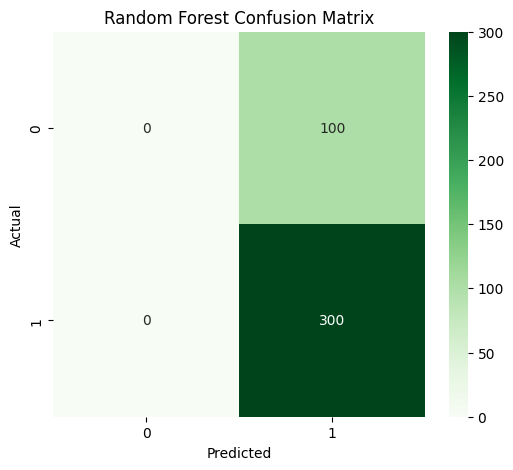

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross Validation Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross Validation Scores: [0.85304659 0.85663082 0.85714286 0.85714286 0.85509839]
Mean F1 Score: 0.8558123047245327


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8567339637107079


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_best_rf))

print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
ROC AUC  : 0.4606


## 3. XGBoost Model

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='binary:logistic',
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.7275
Precision: 0.7493472584856397
Recall   : 0.9566666666666667
F1 Score : 0.8404099560761347
ROC AUC  : 0.4967
              precision    recall  f1-score   support

           0       0.24      0.04      0.07       100
           1       0.75      0.96      0.84       300

    accuracy                           0.73       400
   macro avg       0.49      0.50      0.45       400
weighted avg       0.62      0.73      0.65       400



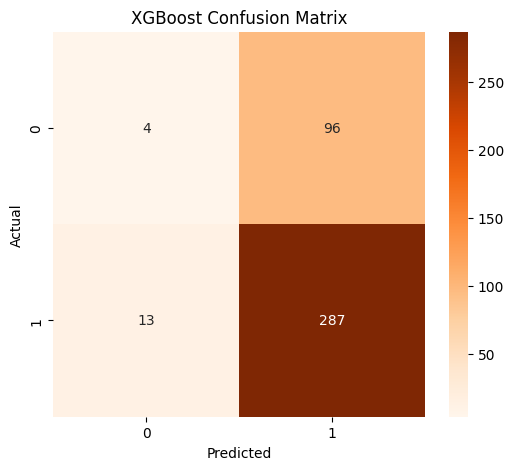

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross Validation Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross Validation Scores: [0.82656827 0.82527881 0.82439926 0.84306569 0.84727273]
Mean F1 Score: 0.8333169514846859


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.8567339637107079


In [ ]:
best_xgb = grid_xgb.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571
ROC AUC  : 0.4504333333333333


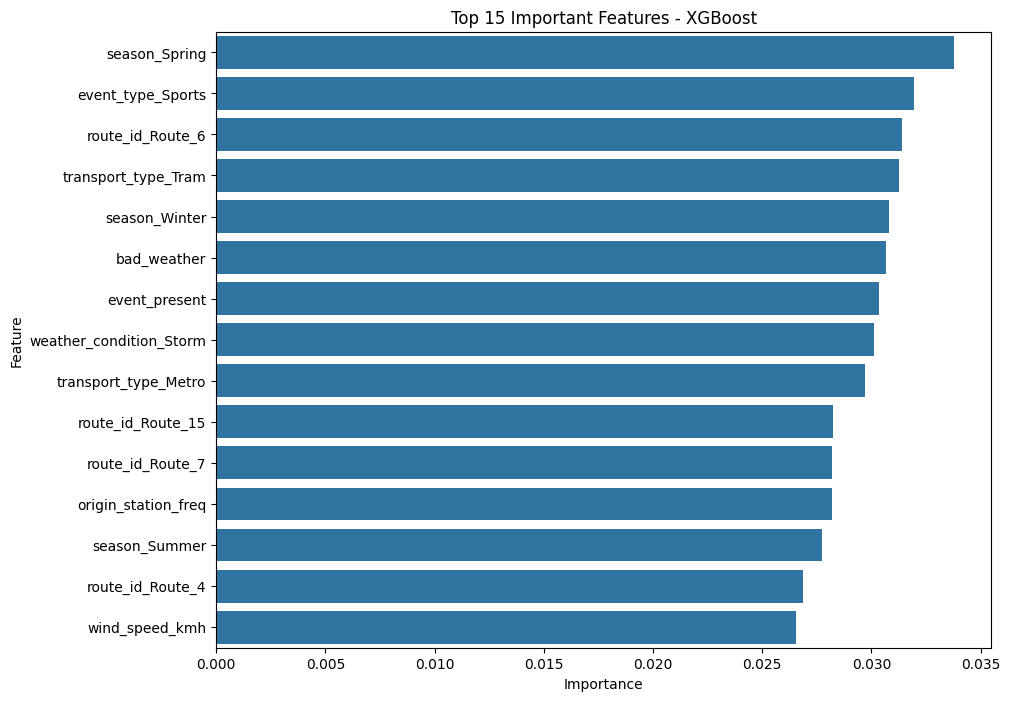

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features - XGBoost")
plt.show()

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        0.75,
        0.75,
        0.7275
    ],
    'Precision': [
        0.75,
        0.75,
        0.7493
    ],
    'Recall': [
        1.00,
        1.00,
        0.9567
    ],
    'F1 Score': [
        0.8571,
        0.8571,
        0.8404
    ],
    'ROC-AUC': [
        0.4095,
        0.5308,
        0.4967
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7500,0.7500,1.0000,0.8571,0.4095
1,Random Forest,0.7500,0.7500,1.0000,0.8571,0.5308
2,XGBoost,0.7275,0.7493,0.9567,0.8404,0.4967


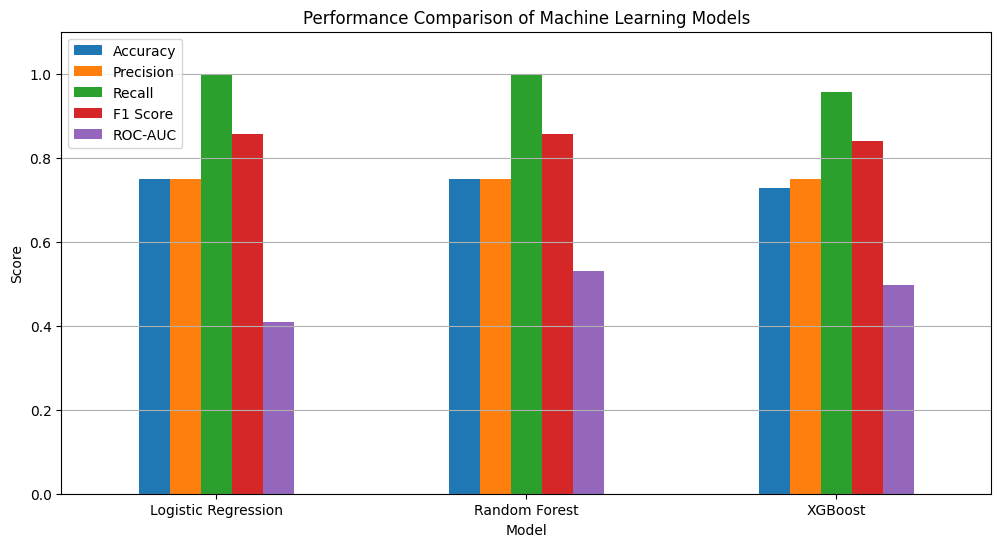

In [ ]:
import matplotlib.pyplot as plt

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0,1.1)
plt.grid(axis='y')
plt.xticks(rotation=0)

plt.show()

In [ ]:
best_model = comparison_df.loc[
    comparison_df['ROC-AUC'].idxmax()
]

print("Best Model Based on ROC-AUC")
print(best_model)

Best Model Based on ROC-AUC
Model        Random Forest
Accuracy              0.75
Precision             0.75
Recall                 1.0
F1 Score            0.8571
ROC-AUC             0.5308
Name: 1, dtype: object


In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
origin_freq = df['origin_station'].value_counts().to_dict()
destination_freq = df['destination_station'].value_counts().to_dict()

joblib.dump(origin_freq, "origin_station_freq.pkl")
joblib.dump(destination_freq, "destination_station_freq.pkl")

KeyError: 'origin_station'

In [ ]:
df_original = pd.read_csv("public_transport_delays.csv")

In [ ]:
origin_freq = df_original['origin_station'].value_counts().to_dict()
destination_freq = df_original['destination_station'].value_counts().to_dict()